# Digital Twin — Battery SOC Estimation (Colab Training)

Physics-informed LSTM vs Vanilla LSTM for SOC estimation of the Panasonic 18650PF battery.

This notebook:
1. Clones the project repo and sets up the environment
2. Loads data and creates DataLoaders
3. Trains the **Vanilla LSTM** (MSE loss only)
4. Trains the **Physics-Informed LSTM** (MSE + physics loss)
5. Compares both models on all test cycles

Trained models and per-epoch CSV stats are saved to `trained_models/`.

## 1. Setup — Clone Repo & Check GPU

In [1]:
import os
import sys

REPO_URL = "https://github.com/juanaponterojas01/Digital_Twin_Battery_with_LSTM.git"
REPO_DIR = "/content/Digital_Twin_Battery_with_LSTM"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/Digital_Twin_Battery_with_LSTM'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 177 (delta 23), reused 41 (delta 16), pack-reused 118 (from 2)
Receiving objects: 100% (177/177), 79.89 MiB | 13.86 MiB/s, done.
Resolving deltas: 100% (44/44), done.
Updating files: 100% (107/107), done.
Working directory: /content/Digital_Twin_Battery_with_LSTM


In [2]:
!nvidia-smi

Sun Apr 19 21:39:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q torch torchvision scikit-learn

import torch
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Imports & Configuration

In [4]:
import importlib
import os
import torch

import config
importlib.reload(config)

from dataset import create_dataloaders
from engine import train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config.DEVICE = str(device)
trained_dir = os.path.join(config.PROJECT_DIR, "trained_models")
print(f"Using device: {device}")
print(f"Save directory: {trained_dir}")

Using device: cuda
Save directory: /content/Digital_Twin_Battery_with_LSTM/trained_models


## 3. Create DataLoaders

In [5]:
train_loader, val_loader, test_loaders = create_dataloaders()

Train: LA92 — 140,675 windows
Val:   US06 — 240 windows
Test:  Cycle1 — 548 windows
Test:  Cycle2 — 556 windows
Test:  Cycle3 — 512 windows
Test:  Cycle4 — 604 windows
Test:  HWFTa — 379 windows
Test:  HWFTb — 379 windows
Test:  UDDS — 1,120 windows
Test:  NN — 584 windows


## 4. Train Vanilla LSTM (MSE Loss Only)

In [6]:
vanilla_model, vanilla_results = train_model(
    is_physics=False,
    beta=0.0,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loaders=test_loaders,
)


Training: vanilla_lstm
Device: cuda
Physics: False  Beta: 0.0

Model parameters: 17,473

Epoch   0/100  train=0.001111  val=0.002480  val_RMSE=0.0489  lr=1.0e-03  [9s]
Epoch   1/100  train=0.000136  val=0.002498  val_RMSE=0.0491  lr=1.0e-03  [18s]
Epoch   2/100  train=0.000097  val=0.002514  val_RMSE=0.0492  lr=1.0e-03  [27s]
Epoch   3/100  train=0.000075  val=0.002345  val_RMSE=0.0475  lr=1.0e-03  [36s]
Epoch   4/100  train=0.000067  val=0.002630  val_RMSE=0.0502  lr=1.0e-03  [45s]
Epoch   5/100  train=0.000061  val=0.002422  val_RMSE=0.0484  lr=1.0e-03  [54s]
Epoch   6/100  train=0.000056  val=0.002190  val_RMSE=0.0460  lr=1.0e-03  [63s]
Epoch   7/100  train=0.000052  val=0.002458  val_RMSE=0.0487  lr=1.0e-03  [72s]
Epoch   8/100  train=0.000048  val=0.002370  val_RMSE=0.0478  lr=1.0e-03  [81s]
Epoch   9/100  train=0.000045  val=0.002411  val_RMSE=0.0481  lr=1.0e-03  [90s]
Epoch  10/100  train=0.000043  val=0.002470  val_RMSE=0.0488  lr=1.0e-03  [99s]
Epoch  11/100  train=0.000041  

## 5. Train Physics-Informed LSTM (MSE + Physics Loss)

In [7]:
physics_model, physics_results = train_model(
    is_physics=True,
    beta=config.BETA,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loaders=test_loaders,
)


Training: physics_lstm_beta_0.1
Device: cuda
Physics: True  Beta: 0.1

Model parameters: 17,473

OCV polynomial degree: 7
R_in polynomial degree: 3
Alpha=1.0, Beta=0.1

Epoch   0/100  train=0.001614 (ml=0.001234 phys=0.003799)  val=0.004185 (ml=0.002724 phys=0.014609)  val_RMSE=0.0512  lr=1.0e-03  [11s]
Epoch   1/100  train=0.000467 (ml=0.000166 phys=0.003012)  val=0.003867 (ml=0.002399 phys=0.014681)  val_RMSE=0.0481  lr=1.0e-03  [22s]
Epoch   2/100  train=0.000430 (ml=0.000129 phys=0.003011)  val=0.004115 (ml=0.002611 phys=0.015047)  val_RMSE=0.0502  lr=1.0e-03  [33s]
Epoch   3/100  train=0.000412 (ml=0.000110 phys=0.003015)  val=0.003984 (ml=0.002468 phys=0.015159)  val_RMSE=0.0488  lr=1.0e-03  [44s]
Epoch   4/100  train=0.000402 (ml=0.000100 phys=0.003019)  val=0.003966 (ml=0.002445 phys=0.015208)  val_RMSE=0.0486  lr=1.0e-03  [55s]
Epoch   5/100  train=0.000395 (ml=0.000093 phys=0.003020)  val=0.004126 (ml=0.002592 phys=0.015339)  val_RMSE=0.0501  lr=1.0e-03  [66s]
Epoch   6/100 

## 7. Training Curves Visualization

/tmp/ipykernel_8660/4064369116.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


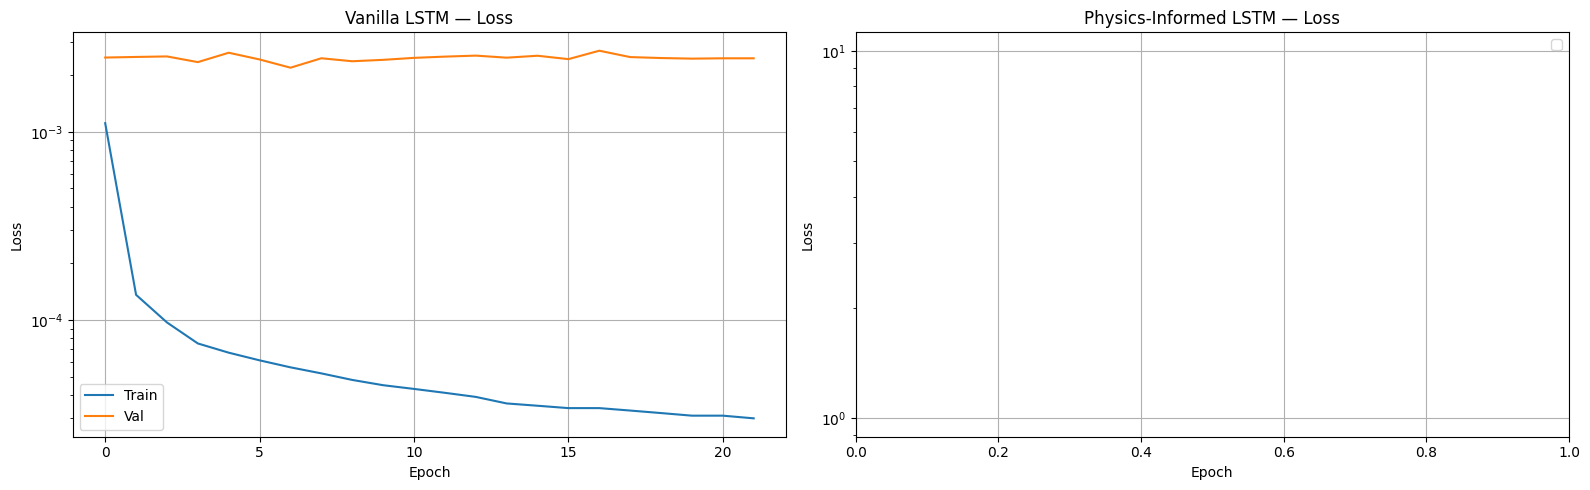

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vanilla_csv = os.path.join(trained_dir, "training_stats_vanilla_lstm.csv")
physics_csv = os.path.join(trained_dir, f"training_stats_physics_lstm_beta_{config.BETA}.csv")

if os.path.isfile(vanilla_csv):
    df_v = pd.read_csv(vanilla_csv)
    axes[0].plot(df_v["epoch"], [float(v) for v in df_v["train_loss"]], label="Train")
    axes[0].plot(df_v["epoch"], [float(v) for v in df_v["val_loss"]], label="Val")
axes[0].set_title("Vanilla LSTM — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale("log")

if os.path.isfile(physics_csv):
    df_p = pd.read_csv(physics_csv)
    axes[1].plot(df_p["epoch"], [float(v) for v in df_p["train_loss"]], label="Train")
    axes[1].plot(df_p["epoch"], [float(v) for v in df_p["val_loss"]], label="Val")
axes[1].set_title("Physics-Informed LSTM — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

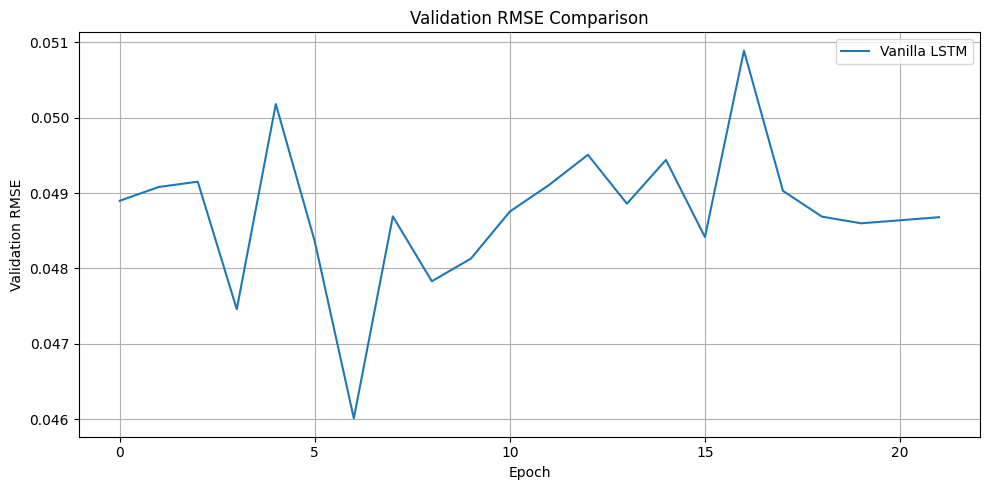

In [10]:
# Validation RMSE over epochs for both models
fig, ax = plt.subplots(figsize=(10, 5))

if os.path.isfile(vanilla_csv):
    df_v = pd.read_csv(vanilla_csv)
    ax.plot(df_v["epoch"], [float(v) for v in df_v["val_rmse"]], label="Vanilla LSTM", color="tab:blue")
if os.path.isfile(physics_csv):
    df_p = pd.read_csv(physics_csv)
    ax.plot(df_p["epoch"], [float(v) for v in df_p["val_rmse"]], label="Physics-Informed LSTM", color="tab:orange")

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation RMSE")
ax.set_title("Validation RMSE Comparison")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Download Training Results

In [1]:
!zip -r /content/trained_models.zip /content/Digital_Twin_Battery_with_LSTM/trained_models/

	zip warning: name not matched: /content/Digital_Twin_Battery_with_LSTM/trained_models/

zip error: Nothing to do! (try: zip -r /content/trained_models.zip . -i /content/Digital_Twin_Battery_with_LSTM/trained_models/)


In [13]:
from google.colab import files
files.download("/content/trained_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>